<img src="../../../images/bwHPC_Logo_cmyk.svg" width="200" /> <img src="../../../images/HochschuleEsslingen_Logo_RGB_DE.png" width="200" /> <img src="../../../images/Konstanz_Logo.svg" width="200" /> <img src="../../../images/KIT_Logo.png" width="200" />

# Autoencoders

Every network so far in this chapter was given a **target** to aim at: an admission
decision, a house price, a cat-or-dog label. Someone had to decide what the right
answer was before training could start.

An **autoencoder** does without that. It is trained to reproduce **its own input** —
the data is both the question and the answer — and the interesting part is that it
is not allowed to do so comfortably. In the middle of the network sits a deliberate
bottleneck, far too small to hold the whole image. To get anything through it, the
network has to work out what is worth keeping.

The task in this notebook is **denoising**: we take images of handwritten digits,
sprinkle random noise over them, and train an autoencoder to recover the clean
original.

---

## Contents

1. [What an autoencoder is](#idea)
2. [The data](#data)
3. [Adding noise](#noise)
4. [Building the autoencoder](#build)
5. [Training](#train)
6. [The result](#result)
7. [Sources and licence](#sources)

<a id="idea"></a>
## 1. What an autoencoder is

An autoencoder is built from three parts:

- the **encoder** compresses the input into a smaller, denser representation
- the **bottleneck** is that compressed form — the output of the encoder and the
  input of the decoder, holding only what survived the squeeze
- the **decoder** takes the compressed form and rebuilds the original as closely as
  it can

![An autoencoder](../../../images/autoencoder_architecture.svg)

The bottleneck is the whole point. If the network were the same width throughout, the
shortest path to reproducing its input would be to copy it straight through, and it
would learn nothing. Forcing everything through a narrow middle means something has
to be discarded, and training is what teaches the network *which* something.

That makes autoencoders useful for noise reduction, compression, dimensionality
reduction and feature extraction — tasks where it is hard to say what the correct
answer even is, so no labelled target could be provided.

**Denoising** is a neat twist on the idea. Instead of feeding the network an image
and asking for that same image back, we feed it a *noisy* image and ask for the
*clean* one. The bottleneck is what makes this work: noise is random and has no
structure worth keeping, so when the network is forced to throw most of the image
away, the noise is the first thing to go.

<a id="data"></a>
## 2. The data

We use **Fashion-MNIST**: 28 × 28 greyscale photographs of Zalando article images —
shirts, shoes, bags and so on — 60,000 for training and 10,000 for testing. Keras
ships it, so `load_data()` fetches and caches it for us.

Each image comes with a label saying which kind of article it is, and that label is
exactly what we do **not** need. The network is going to be trained to reproduce
images, not to name them, so we unpack the labels into `_` and throw them away.

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

print("training images:", x_train.shape)
print("test images:    ", x_test.shape)

Two adjustments before the images can be used.

The pixel values arrive as whole numbers from 0 to 255, and networks train better on
small inputs, so we divide by 255 to put everything between 0 and 1 — the same
rescaling as in the CNN notebook, done here by hand rather than by a layer.

The images are also 28 × 28 with no channel dimension, and convolution layers expect
one. `tf.newaxis` appends it: greyscale, so a single channel.

In [2]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

print("training images:", x_train.shape)
print("pixel range:    ", x_train.min(), "to", x_train.max())

training images: (60000, 28, 28, 1)
pixel range:     0.0 to 1.0


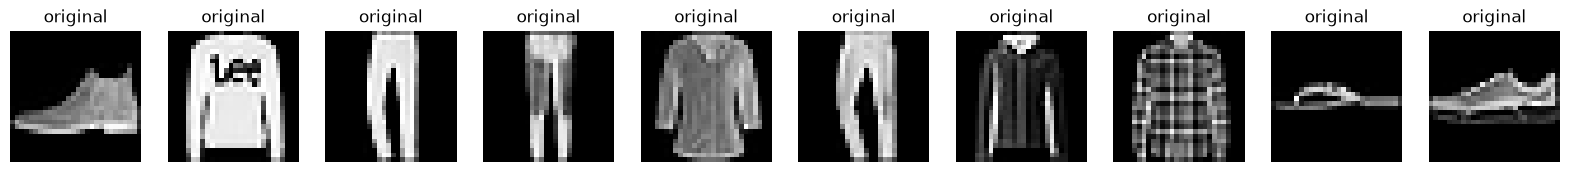

In [3]:
n = 10
plt.figure(figsize=(20, 2))

for i in range(n):
    plt.subplot(1, n, i + 1)
    plt.imshow(tf.squeeze(x_test[i]), cmap="gray")
    plt.title("original")
    plt.axis("off")

plt.show()

<a id="noise"></a>
## 3. Adding noise

Now we ruin them on purpose.

To every pixel we add a random number drawn from a normal distribution, scaled down
by a `noise_factor`. That can push values outside the valid 0–1 range, so
`clip_by_value` pulls anything below 0 or above 1 back to the edge.

This gives us the pair the network needs: **the noisy image as input, the clean
original as the target**. Both come from data we already had — no labelling
required.

In [4]:
noise_factor = 0.2

x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.)

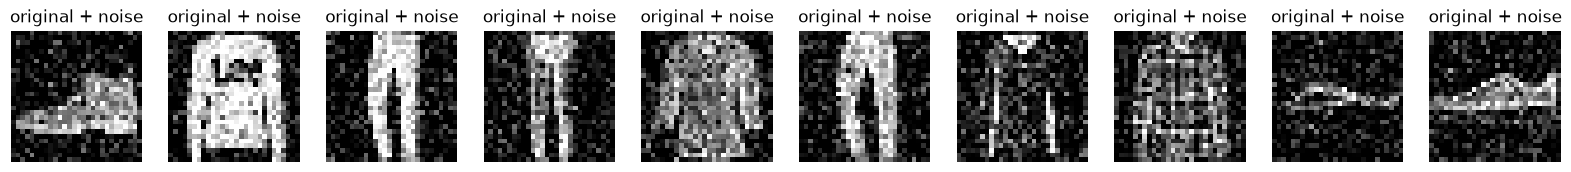

In [5]:
n = 10
plt.figure(figsize=(20, 2))

for i in range(n):
    plt.subplot(1, n, i + 1)
    plt.imshow(tf.squeeze(x_test_noisy[i]), cmap="gray")
    plt.title("original + noise")
    plt.axis("off")

plt.show()

<a id="build"></a>
## 4. Building the autoencoder

Because we are working with images, both halves are built from **convolution
layers** — the sliding-window layers introduced in
[03_Image_Processing_With_CNNs](../03_Image_Processing_With_CNNs/03_Image_Processing_With_CNNs.ipynb).

The encoder uses ordinary `Conv2D` layers with **`strides=2`**, which moves the
window two pixels at a time instead of one and so halves the height and width at
every step. The decoder has to do the reverse, and for that there is
**`Conv2DTranspose`**: same idea, run backwards, doubling height and width instead of
halving them.

This model is written as a **class** rather than as a `Sequential` list, because we
want to keep the encoder and the decoder as two separately usable pieces. `call`
defines what happens to an image: through the encoder, then through the decoder.

In [6]:
class Denoise(tf.keras.Model):
    def __init__(self):
        super().__init__()

        self.encoder = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(28, 28, 1)),
            tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same', strides=2),
            tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same', strides=2),
        ])

        self.decoder = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(7, 7, 8)),   # whatever the encoder produced
            tf.keras.layers.Conv2DTranspose(8, kernel_size=3, strides=2, activation='relu', padding='same'),
            tf.keras.layers.Conv2DTranspose(16, kernel_size=3, strides=2, activation='relu', padding='same'),
            tf.keras.layers.Conv2D(1, kernel_size=(3, 3), activation='sigmoid', padding='same'),
        ])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


autoencoder = Denoise()

The compression comes from two things at once: the stride of 2 shrinks the image,
and the number of filters drops from 16 to 8.

The encoder summary shows exactly how far it goes.

In [7]:
autoencoder.encoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,320 (5.16 KB)

 Trainable params: 1,320 (5.16 KB)

 Non-trainable params: 0 (0.00 B)

28 × 28 × 1 becomes 14 × 14 × 16, then **7 × 7 × 8**. That last shape is the
bottleneck: 392 numbers where the image had 784. Every image has to pass through a
representation **half its original size**.

The decoder walks the same path backwards.

In [8]:
autoencoder.decoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_transpose                │ (None, 14, 14, 8)      │           584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 16)     │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,897 (7.41 KB)

 Trainable params: 1,897 (7.41 KB)

 Non-trainable params: 0 (0.00 B)

<a id="train"></a>
## 5. Training

One thing is different from every other network in this chapter, and it is the whole
idea in a single line of code:

```python
autoencoder.fit(x_train_noisy, x_train, ...)
```

The input is the **noisy** batch and the target is the **clean** batch. There is no
label column anywhere.

The loss is the **mean squared error** between the rebuilt image and the clean
original, compared pixel by pixel — the same MSE met in the Machine Learning
chapter, applied here to 784 pixels instead of a single number.

In [9]:
autoencoder.compile(optimizer='adam', loss=tf.keras.losses.MeanSquaredError())

In [10]:
autoencoder.fit(x_train_noisy, x_train,
                epochs=5,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0183 - val_loss: 0.0107
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0098 - val_loss: 0.0093
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0090 - val_loss: 0.0089
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0086 - val_loss: 0.0085
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0084 - val_loss: 0.0083


<a id="result"></a>
## 6. The result

Because we kept the two halves separate, we can run them one at a time and look at
what comes out of the middle.

In [12]:
encoded_imgs = autoencoder.encoder(x_test_noisy).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

print("noisy input:", x_test_noisy.shape)
print("bottleneck: ", encoded_imgs.shape)
print("rebuilt:    ", decoded_imgs.shape)

noisy input: (10000, 28, 28, 1)
bottleneck:  (10000, 7, 7, 8)
rebuilt:     (10000, 28, 28, 1)


Three rows: what the network was given, what it produced, and what it was aiming
at.

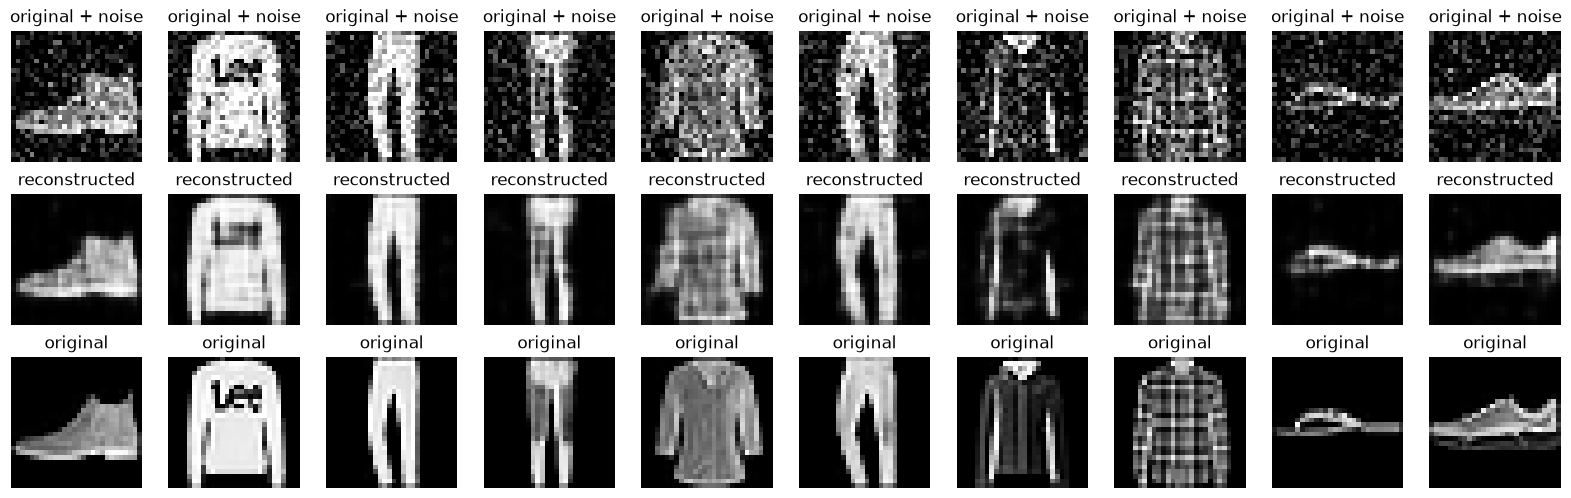

In [13]:
n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(tf.squeeze(x_test_noisy[i]), cmap="gray")
    plt.title("original + noise")
    plt.axis("off")

    plt.subplot(3, n, i + n + 1)
    plt.imshow(tf.squeeze(decoded_imgs[i]), cmap="gray")
    plt.title("reconstructed")
    plt.axis("off")

    plt.subplot(3, n, i + 2 * n + 1)
    plt.imshow(tf.squeeze(x_test[i]), cmap="gray")
    plt.title("original")
    plt.axis("off")

plt.show()

The middle row is noticeably cleaner than the top one, and close to the bottom one —
and the network was never told what a digit is, nor what noise is. It was only ever
asked to squeeze an image through a gap half its size and put it back together.

Look closely and the reconstructions are also slightly **blurrier** than the
originals. That is not a flaw to be fixed; it is the bottleneck doing its job. Fine
detail is exactly what does not fit through 392 numbers, and the network sacrificed
it — along with the noise, which is what we wanted.

<a id="sources"></a>
## 7. Sources and licence

This notebook is mainly based on the TensorFlow tutorial
**[Intro to Autoencoders](https://www.tensorflow.org/tutorials/generative/autoencoder)**.

That tutorial is published under the Apache License, Version 2.0, reproduced below. Changes have been made to the original notebook.

In [14]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

### References

The content of this workshop is in parts also based on and inspired by the following
sources:

* Python Course of the AG Peter (Prof. Dr. Christine Peter, Kevin Savade, Dr. Oleksandra Kukharenko, Dr. Andrej Berg)
* Software Carpentry workshops (https://software-carpentry.org/lessons/)
* Online KI Kurs des Bundeswettbewerbs Künstliche Intelligenz (https://ki-kurs.org/)
* Real Python (https://realpython.com/)
* Image classification of MNIST using TensorFlow (https://www.kaggle.com/code/viratkothari/image-classification-of-mnist-using-tensorflow)
* The bwHPC wiki (https://wiki.bwhpc.de/)